# Seoul Bike Sharing Demand — análisis exploratorio

**Autor:** Francisco de la Corte  
**Fuente:** UCI Machine Learning Repository  
**Estado:** fase 1 — planteamiento, carga y auditoría inicial

> El análisis es descriptivo: identifica patrones y asociaciones en datos históricos, pero no demuestra causalidad.

## 1. Problema y propósito

Los sistemas públicos de bicicletas necesitan ajustar su disponibilidad a una demanda que cambia según la hora, el calendario y las condiciones meteorológicas.

**Pregunta principal:** ¿Cómo varía la demanda horaria del sistema público de bicicletas de Seúl en función del tiempo, las condiciones meteorológicas, la estación y los días festivos, y qué recomendaciones operativas pueden extraerse para mejorar la disponibilidad del servicio?

**Audiencia:** responsables de movilidad urbana y gestores del servicio.

**Uso previsto:** apoyar decisiones operativas y mostrar un proceso de análisis reproducible.

## 2. Preguntas analíticas

1. ¿Cuáles son las horas y los días con mayor y menor demanda?
2. ¿Cómo cambia la demanda entre estaciones?
3. ¿Qué diferencias aparecen entre festivos y días ordinarios?
4. ¿Cómo se relacionan temperatura, lluvia, nieve y humedad con los alquileres?
5. ¿Existen observaciones atípicas o periodos anómalos?
6. ¿Cuándo convendría reforzar o reducir la disponibilidad?
7. ¿Qué conclusiones son descriptivas y cuáles requerirían un modelo predictivo?

## 3. Fuente y límites iniciales

- Dataset: **Seoul Bike Sharing Demand**.
- Fuente oficial: https://archive.ics.uci.edu/dataset/560/seoul%2Bbike%2Bsharing%2Bdemand
- DOI: https://doi.org/10.24432/C5F62R
- Unidad de observación: una hora.
- Cobertura declarada: 8.760 observaciones.
- UCI no declara valores ausentes.
- Los resultados no deben generalizarse automáticamente a otras ciudades o periodos.

## 4. Carga reproducible

Se utiliza el identificador permanente de UCI. Se combinan variables predictoras y objetivo evitando columnas duplicadas.

In [4]:
# Instalación de la librería necesaria para descargar el dataset desde UCI
%pip install -q ucimlrepo

# Librerías
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Configuración
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")

# Semilla para garantizar resultados reproducibles
RANDOM_STATE = 42

print("Librerías instaladas e importadas correctamente.")

Librerías instaladas e importadas correctamente.


In [5]:
dataset = fetch_ucirepo(id=560)

features = dataset.data.features.copy()
targets = dataset.data.targets.copy() if dataset.data.targets is not None else pd.DataFrame()

if not targets.empty:
    new_target_columns = [c for c in targets.columns if c not in features.columns]
    df_raw = pd.concat([features, targets[new_target_columns]], axis=1)
else:
    df_raw = features.copy()

df = df_raw.copy()
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
display(df.head())

Dimensiones: 8,760 filas × 14 columnas


,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
# Metadatos y diccionario facilitados por UCI
display(dataset.variables)
print(dataset.metadata.get("name", "Seoul Bike Sharing Demand"))

,name,role,type,demographic,description,units,missing_values
0,Date,Feature,Date,None,None,None,no
1,Rented Bike Count,Feature,Integer,None,None,None,no
2,Hour,Feature,Integer,None,None,None,no
3,Temperature,Feature,Continuous,None,None,C,no
4,Humidity,Feature,Integer,None,None,%,no
5,Wind speed,Feature,Continuous,None,None,m/s,no
6,Visibility,Feature,Integer,None,None,10m,no
7,Dew point temperature,Feature,Continuous,None,None,C,no
8,Solar Radiation,Feature,Continuous,None,None,Mj/m2,no
9,Rainfall,Feature,Integer,None,None,mm,no


Seoul Bike Sharing Demand


## 5. Auditoría inicial de calidad

Antes de limpiar o representar datos se comprueban dimensiones, tipos, ausencias, duplicados y cardinalidad. Cualquier transformación posterior deberá justificarse.

In [7]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_n": df.nunique(dropna=False)
}).sort_values(["missing_pct", "unique_n"], ascending=[False, True])

print(f"Filas duplicadas completas: {df.duplicated().sum():,}")
display(audit)

Filas duplicadas completas: 0


,dtype,missing_n,missing_pct,unique_n
Holiday,object,0,0.0,2
Functioning Day,object,0,0.0,2
Seasons,object,0,0.0,4
Hour,int64,0,0.0,24
Snowfall,float64,0,0.0,51
Rainfall,float64,0,0.0,61
Wind speed,float64,0,0.0,65
Humidity,int64,0,0.0,90
Solar Radiation,float64,0,0.0,345
Date,object,0,0.0,365


In [8]:
# Resumen descriptivo sin modificar todavía los datos
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,30/11/2018,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature,8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity,8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed,8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility,8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature,8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation,8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall,8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


## 6. Validaciones de coherencia

Antes de limpiar los datos se revisan la cobertura temporal, las interrupciones del servicio, los registros con demanda igual a cero y los rangos de las variables meteorológicas.

In [10]:
# Validaciones de coherencia antes de limpiar

print("Rango de fechas:")
print(df["Date"].min(), "→", df["Date"].max())

print("\nDistribución del funcionamiento del servicio:")
display(
    df["Functioning Day"]
    .value_counts(dropna=False)
    .to_frame("Número de horas")
)

print("\nRegistros con demanda igual a cero:")
print((df["Rented Bike Count"] == 0).sum())

print("\nDemanda cero según funcionamiento del servicio:")
display(
    pd.crosstab(
        df["Functioning Day"],
        df["Rented Bike Count"] == 0,
        rownames=["Servicio operativo"],
        colnames=["Demanda igual a cero"]
    )
)

print("\nValores mínimos y máximos de las variables meteorológicas:")
display(
    df[
        [
            "Temperature",
            "Humidity",
            "Wind speed",
            "Visibility",
            "Solar Radiation",
            "Rainfall",
            "Snowfall"
        ]
    ].agg(["min", "max"]).T
)

Rango de fechas:
1/1/2018 → 9/9/2018

Distribución del funcionamiento del servicio:


,Número de horas
Functioning Day,
Yes,8465
No,295



Registros con demanda igual a cero:
295

Demanda cero según funcionamiento del servicio:


Demanda igual a cero,False,True
Servicio operativo,,
No,0,295
Yes,8465,0



Valores mínimos y máximos de las variables meteorológicas:


,min,max
Temperature,-17.8,39.40
Humidity,0.0,98.00
Wind speed,0.0,7.40
Visibility,27.0,2000.00
Solar Radiation,0.0,3.52
Rainfall,0.0,35.00
Snowfall,0.0,8.80


## 7. Preparación y transformación

Se convierte la fecha a un formato temporal válido, se construye una marca temporal horaria y se separan las horas operativas para analizar la demanda realmente observada. El dataset original se conserva sin modificar.

In [12]:
# Copia de trabajo: el dataframe original se conserva sin modificar
df_clean = df.copy()

# Conversión explícita del formato día/mes/año
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Comprobación de fechas no interpretadas
print("Fechas no interpretadas:", df_clean["Date"].isna().sum())

# Creación de una marca temporal completa
df_clean["Datetime"] = (
    df_clean["Date"]
    + pd.to_timedelta(df_clean["Hour"], unit="h")
)

print(
    "Rango temporal correcto:",
    df_clean["Datetime"].min(),
    "→",
    df_clean["Datetime"].max()
)

# Separación de las horas con servicio operativo
df_operational = df_clean[
    df_clean["Functioning Day"] == "Yes"
].copy()

print(f"\nDataset completo: {len(df_clean):,} registros")
print(f"Horas operativas: {len(df_operational):,} registros")
print(
    "Ceros de demanda en horas operativas:",
    (df_operational["Rented Bike Count"] == 0).sum()
)

# Inspección del valor potencialmente sospechoso de humedad
print("\nRegistros con humedad igual a 0 %:")
display(
    df_clean.loc[
        df_clean["Humidity"] == 0,
        [
            "Datetime",
            "Temperature",
            "Humidity",
            "Dew point temperature",
            "Rented Bike Count",
            "Functioning Day"
        ]
    ]
)

Fechas no interpretadas: 0
Rango temporal correcto: 2017-12-01 00:00:00 → 2018-11-30 23:00:00

Dataset completo: 8,760 registros
Horas operativas: 8,465 registros
Ceros de demanda en horas operativas: 0

Registros con humedad igual a 0 %:


,Datetime,Temperature,Humidity,Dew point temperature,Rented Bike Count,Functioning Day
4063,2018-05-19 07:00:00,11.4,0,4.5,436,Yes
4106,2018-05-21 02:00:00,13.9,0,-2.1,262,Yes
4107,2018-05-21 03:00:00,13.0,0,-2.5,165,Yes
4108,2018-05-21 04:00:00,12.4,0,-3.4,113,Yes
4109,2018-05-21 05:00:00,11.9,0,-2.7,200,Yes
4110,2018-05-21 06:00:00,11.4,0,-2.0,467,Yes
4111,2018-05-21 07:00:00,12.3,0,-2.7,1135,Yes
4131,2018-05-22 03:00:00,15.5,0,10.4,406,Yes
4132,2018-05-22 04:00:00,15.6,0,10.5,248,Yes
4133,2018-05-22 05:00:00,15.7,0,10.6,182,Yes


## 8. Tratamiento de anomalías de calidad

Se detectaron 17 registros con humedad relativa igual a 0 %, concentrados entre el 19 y el 28 de mayo de 2018. Estos valores son incompatibles con la temperatura y el punto de rocío registrados, por lo que se consideran fallos puntuales de medición.

La humedad se estima mediante la fórmula de Magnus utilizando la temperatura y el punto de rocío. Se conserva la variable original para mantener la trazabilidad.

In [13]:
# Conservación de la humedad original
df_clean["Humidity_original"] = df_clean["Humidity"]

# Registros que requieren corrección
humidity_mask = df_clean["Humidity"].eq(0)

# Estimación de humedad relativa mediante la fórmula de Magnus
a = 17.625
b = 243.04

temperature = df_clean["Temperature"]
dew_point = df_clean["Dew point temperature"]

estimated_humidity = 100 * np.exp(
    (a * dew_point / (b + dew_point))
    - (a * temperature / (b + temperature))
)

# La columna pasa a decimal para admitir valores estimados
df_clean["Humidity"] = df_clean["Humidity"].astype(float)

df_clean.loc[humidity_mask, "Humidity"] = (
    estimated_humidity[humidity_mask]
    .clip(0, 100)
    .round(1)
)

print("Registros corregidos:", humidity_mask.sum())

display(
    df_clean.loc[
        humidity_mask,
        [
            "Datetime",
            "Temperature",
            "Dew point temperature",
            "Humidity_original",
            "Humidity"
        ]
    ]
)

# Actualización del subconjunto operativo
df_operational = df_clean[
    df_clean["Functioning Day"] == "Yes"
].copy()

Registros corregidos: 17


,Datetime,Temperature,Dew point temperature,Humidity_original,Humidity
4063,2018-05-19 07:00:00,11.4,4.5,0,62.5
4106,2018-05-21 02:00:00,13.9,-2.1,0,33.1
4107,2018-05-21 03:00:00,13.0,-2.5,0,34.0
4108,2018-05-21 04:00:00,12.4,-3.4,0,33.1
4109,2018-05-21 05:00:00,11.9,-2.7,0,36.0
4110,2018-05-21 06:00:00,11.4,-2.0,0,39.2
4111,2018-05-21 07:00:00,12.3,-2.7,0,35.1
4131,2018-05-22 03:00:00,15.5,10.4,0,71.6
4132,2018-05-22 04:00:00,15.6,10.5,0,71.7
4133,2018-05-22 05:00:00,15.7,10.6,0,71.7


## 9. Análisis univariante de la demanda

Se analiza la distribución de bicicletas alquiladas únicamente durante las horas en las que el servicio estuvo operativo. Los posibles valores atípicos se identifican para estudiarlos, pero no se eliminan automáticamente.

,Rented Bike Count
count,8465.000000
mean,729.156999
std,642.351166
min,2.000000
1%,17.000000
5%,49.000000
25%,214.000000
50%,542.000000
75%,1084.000000
95%,2058.800000


Límite inferior IQR: -1,091.0
Límite superior IQR: 2,389.0
Registros fuera de los límites IQR: 152
Porcentaje sobre las horas operativas: 1.80%


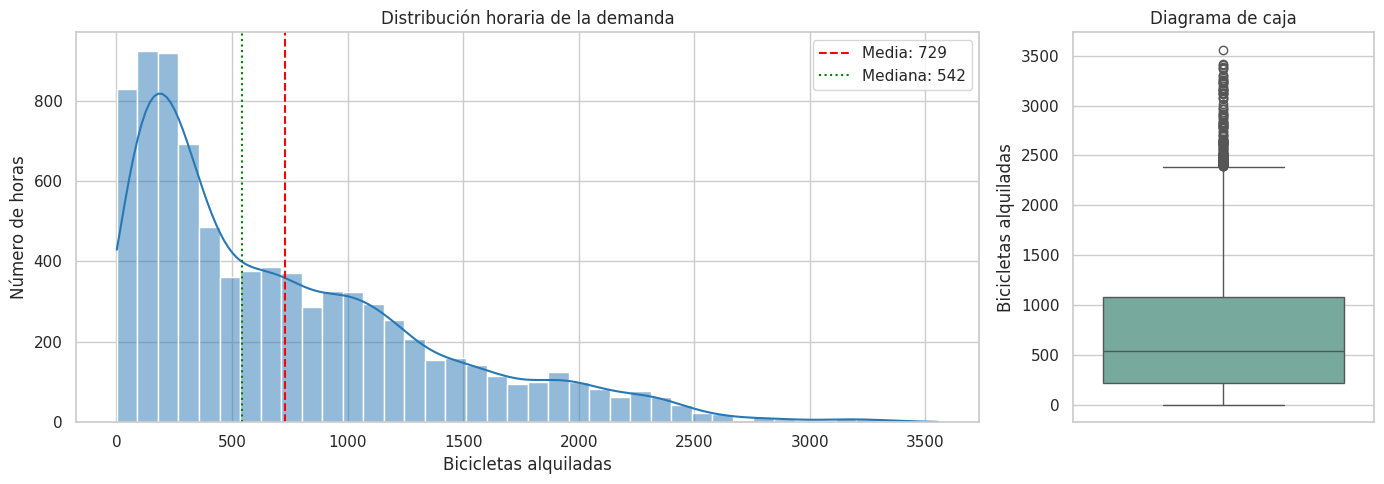

In [14]:
# Variable principal durante las horas operativas
demand = df_operational["Rented Bike Count"]

# Resumen con percentiles adicionales
demand_summary = demand.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame("Rented Bike Count")

display(demand_summary)

# Identificación descriptiva de valores extremos mediante el criterio IQR
q1 = demand.quantile(0.25)
q3 = demand.quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

extreme_values = demand[
    (demand < lower_limit) | (demand > upper_limit)
]

print(f"Límite inferior IQR: {lower_limit:,.1f}")
print(f"Límite superior IQR: {upper_limit:,.1f}")
print(f"Registros fuera de los límites IQR: {len(extreme_values):,}")
print(
    "Porcentaje sobre las horas operativas:",
    f"{len(extreme_values) / len(demand) * 100:.2f}%"
)

# Distribución y diagrama de caja
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

sns.histplot(
    demand,
    bins=40,
    kde=True,
    ax=axes[0],
    color="#2878B5"
)

axes[0].axvline(
    demand.mean(),
    color="red",
    linestyle="--",
    label=f"Media: {demand.mean():.0f}"
)

axes[0].axvline(
    demand.median(),
    color="green",
    linestyle=":",
    label=f"Mediana: {demand.median():.0f}"
)

axes[0].set_title("Distribución horaria de la demanda")
axes[0].set_xlabel("Bicicletas alquiladas")
axes[0].set_ylabel("Número de horas")
axes[0].legend()

sns.boxplot(
    y=demand,
    ax=axes[1],
    color="#6FB1A0"
)

axes[1].set_title("Diagrama de caja")
axes[1].set_ylabel("Bicicletas alquiladas")

plt.tight_layout()
plt.show()

### Interpretación provisional

Durante las horas operativas, la demanda media fue de 729 bicicletas por hora, mientras que la mediana fue de 542. La diferencia entre ambas medidas y la forma del histograma indican una distribución asimétrica hacia valores altos.

El 50 % central de las observaciones se sitúa entre 214 y 1.084 alquileres por hora. El criterio IQR identifica 152 observaciones por encima de 2.389 alquileres, equivalentes al 1,80 % de las horas operativas.

Estas observaciones no se eliminan: el criterio IQR señala valores poco frecuentes, pero no demuestra que sean errores. Deben contextualizarse según la hora, la fecha, la estación y las condiciones meteorológicas.

## 10. Contextualización de las demandas altas

Se examina cuándo ocurrieron las observaciones superiores al límite IQR para determinar si corresponden a patrones temporales plausibles, como horas punta, o a posibles errores.

In [15]:
# Identificación de las demandas superiores al límite IQR
df_operational["High_demand_IQR"] = (
    df_operational["Rented Bike Count"] > upper_limit
)

# Variables temporales auxiliares
day_names = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

df_operational["Day of week"] = (
    df_operational["Datetime"]
    .dt.dayofweek
    .map(day_names)
)

df_operational["Month"] = df_operational["Datetime"].dt.month

# Concentración de demandas altas por hora
high_demand_by_hour = (
    df_operational
    .groupby("Hour", observed=True)
    .agg(
        horas_observadas=("Rented Bike Count", "size"),
        demandas_altas=("High_demand_IQR", "sum")
    )
)

high_demand_by_hour["porcentaje"] = (
    high_demand_by_hour["demandas_altas"]
    / high_demand_by_hour["horas_observadas"]
    * 100
).round(2)

display(
    high_demand_by_hour.sort_values(
        "demandas_altas",
        ascending=False
    )
)

print("\nQuince demandas horarias más elevadas:")

display(
    df_operational.nlargest(
        15,
        "Rented Bike Count"
    )[
        [
            "Datetime",
            "Rented Bike Count",
            "Day of week",
            "Seasons",
            "Holiday",
            "Temperature",
            "Humidity",
            "Rainfall",
            "Wind speed"
        ]
    ]
)

,horas_observadas,demandas_altas,porcentaje
Hour,,,
18,353,86,24.36
19,353,34,9.63
20,353,15,4.25
17,353,7,1.98
21,353,4,1.13
8,353,4,1.13
16,353,2,0.57
0,352,0,0.00
7,353,0,0.00



Quince demandas horarias más elevadas:


,Datetime,Rented Bike Count,Day of week,Seasons,Holiday,Temperature,Humidity,Rainfall,Wind speed
4818,2018-06-19 18:00:00,3556,Martes,Summer,No Holiday,24.1,57.0,0.0,2.9
4866,2018-06-21 18:00:00,3418,Jueves,Summer,No Holiday,27.8,43.0,0.0,3.0
4650,2018-06-12 18:00:00,3404,Martes,Summer,No Holiday,24.9,53.0,0.0,3.6
4842,2018-06-20 18:00:00,3384,Miércoles,Summer,No Holiday,27.0,55.0,0.0,3.1
4458,2018-06-04 18:00:00,3380,Lunes,Summer,No Holiday,24.4,48.0,0.0,1.9
4890,2018-06-22 18:00:00,3365,Viernes,Summer,No Holiday,29.3,27.0,0.0,3.4
4554,2018-06-08 18:00:00,3309,Viernes,Summer,No Holiday,26.2,54.0,0.0,2.2
6810,2018-09-10 18:00:00,3298,Lunes,Autumn,No Holiday,25.9,42.0,0.0,1.1
6978,2018-09-17 18:00:00,3277,Lunes,Autumn,No Holiday,25.3,56.0,0.0,2.8
6858,2018-09-12 18:00:00,3256,Miércoles,Autumn,No Holiday,27.0,44.0,0.0,1.4


### Interpretación de las demandas altas

Las 152 observaciones superiores al límite IQR presentan un patrón temporal claro y coherente. El 56,6 % ocurre a las 18:00 y el 88,8 % se concentra entre las 18:00 y las 20:00.

Los 15 valores máximos se registraron a las 18:00, en días no festivos, sin lluvia y principalmente durante primavera, verano y otoño. Esta concentración respalda que se trata de horas punta reales y no de errores de medición.

El patrón es compatible con desplazamientos vespertinos recurrentes, aunque los datos disponibles no permiten atribuir causalmente la demanda a los desplazamientos laborales.

**Decisión:** conservar todos los valores altos. La clasificación mediante IQR se utiliza únicamente como herramienta descriptiva.

## 11. Patrones horarios y semanales

Se compara la demanda media y mediana por hora y se representa su interacción con el día de la semana. La media muestra el volumen operativo esperado, mientras que la mediana reduce la influencia de los picos extremos.

,mean,median,std,count
Hour,,,,
0,561.5,531.5,355.8,352
1,441.9,411.5,278.5,352
2,312.8,277.0,205.6,352
3,210.8,183.5,140.3,352
4,137.5,123.5,88.2,352
5,144.2,136.5,93.4,352
6,298.2,245.0,219.8,352
7,626.6,443.0,477.0,353
8,1050.2,767.0,750.6,353


Horas con mayor demanda media:


,mean,median,std,count
Hour,,,,
18,1554.0,1624.0,1007.9,353
19,1235.8,1280.0,842.5,353
17,1177.2,1233.0,731.0,353
20,1105.3,1133.0,782.0,353
21,1066.5,1146.0,741.5,353


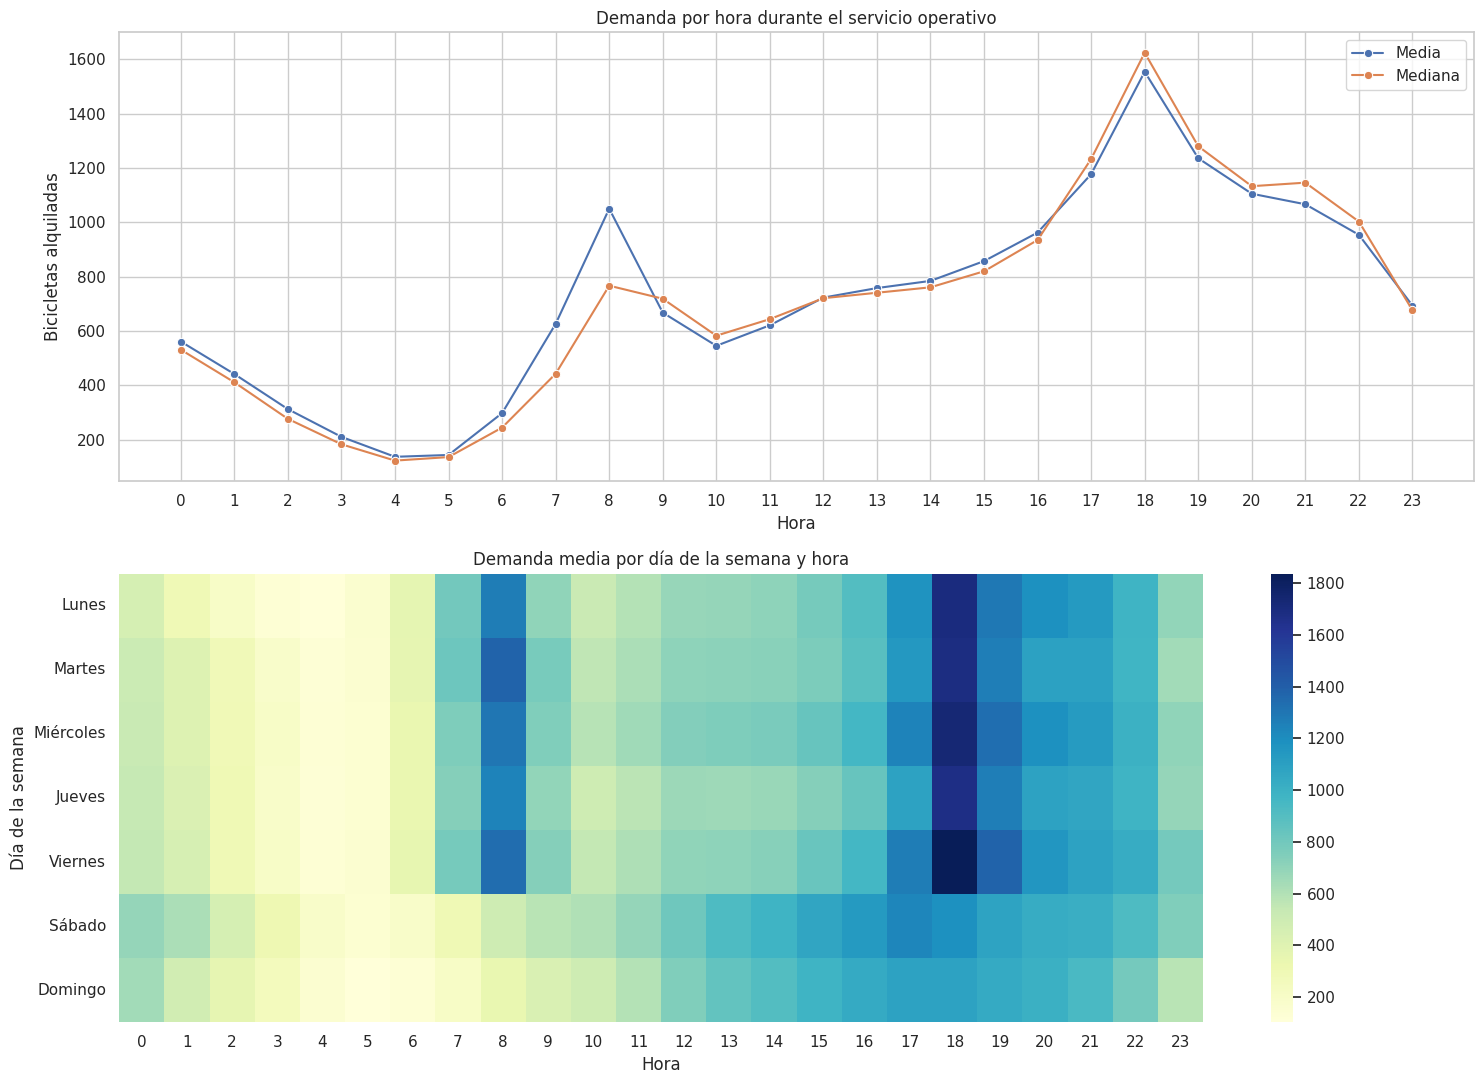

In [16]:
# Orden lógico de los días
day_order = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

df_operational["Day of week"] = pd.Categorical(
    df_operational["Day of week"],
    categories=day_order,
    ordered=True
)

df_operational["Day type"] = np.where(
    df_operational["Datetime"].dt.dayofweek < 5,
    "Laborable",
    "Fin de semana"
)

# Perfil horario
hourly_profile = (
    df_operational
    .groupby("Hour", observed=True)["Rented Bike Count"]
    .agg(["mean", "median", "std", "count"])
    .round(1)
)

display(hourly_profile)

print("Horas con mayor demanda media:")
display(
    hourly_profile
    .sort_values("mean", ascending=False)
    .head(5)
)

# Matriz día-hora
day_hour_demand = df_operational.pivot_table(
    index="Day of week",
    columns="Hour",
    values="Rented Bike Count",
    aggfunc="mean",
    observed=False
)

fig, axes = plt.subplots(2, 1, figsize=(15, 11))

sns.lineplot(
    data=hourly_profile,
    x=hourly_profile.index,
    y="mean",
    marker="o",
    label="Media",
    ax=axes[0]
)

sns.lineplot(
    data=hourly_profile,
    x=hourly_profile.index,
    y="median",
    marker="o",
    label="Mediana",
    ax=axes[0]
)

axes[0].set_title("Demanda por hora durante el servicio operativo")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Bicicletas alquiladas")
axes[0].set_xticks(range(24))

sns.heatmap(
    day_hour_demand,
    cmap="YlGnBu",
    ax=axes[1]
)

axes[1].set_title("Demanda media por día de la semana y hora")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Día de la semana")

plt.tight_layout()
plt.show()

### Interpretación de los patrones horarios

La demanda presenta dos picos diarios. El primero aparece a las 08:00, con una media de 1.050 alquileres por hora. El segundo y más intenso se registra a las 18:00, con una media de 1.554 y una mediana de 1.624 alquileres.

La demanda media de las 18:00 supera aproximadamente en un 48 % a la de las 08:00. Las horas de menor utilización son las 04:00 y 05:00, ambas por debajo de 150 alquileres de media.

A partir de las 15:00 la demanda aumenta progresivamente hasta alcanzar el máximo de las 18:00 y después desciende. Este comportamiento es compatible con desplazamientos recurrentes de mañana y tarde, aunque todavía debe comprobarse si el patrón se concentra en los días laborables.

La elevada dispersión observada en las horas punta indica que la demanda cambia considerablemente según el día, la estación o las condiciones meteorológicas.

## 12. Comparación entre días laborables y fines de semana

Se compara el perfil horario de los días laborables y los fines de semana para comprobar si los picos de las 08:00 y las 18:00 están asociados al calendario semanal.

,Day type,Hour,mean,median,count
17,Fin de semana,17,1161.009804,1029.5,102
18,Fin de semana,18,1135.598039,1049.0,102
16,Fin de semana,16,1090.921569,1025.5,102
19,Fin de semana,19,1061.950980,965.5,102
15,Fin de semana,15,1022.598039,954.0,102
42,Laborable,18,1724.051793,1904.0,251
43,Laborable,19,1306.414343,1377.0,251
32,Laborable,8,1306.015936,1516.0,251
41,Laborable,17,1183.796813,1289.0,251
44,Laborable,20,1140.992032,1208.0,251


,mean,median,count
Day of week,,,
Lunes,730.6,533.0,1248
Martes,745.3,571.5,1152
Miércoles,770.0,570.5,1200
Jueves,718.3,538.0,1200
Viernes,776.4,600.0,1224
Sábado,727.6,560.0,1217
Domingo,637.4,424.0,1224


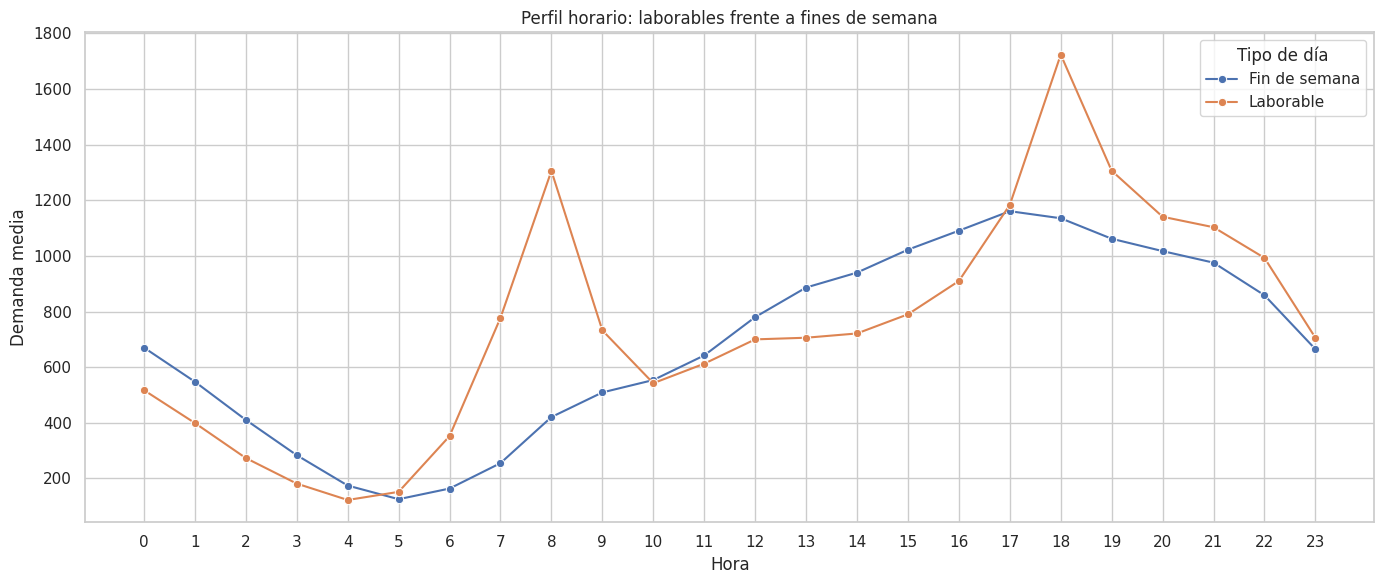

In [17]:
# Perfil horario según tipo de día
day_type_hour = (
    df_operational
    .groupby(
        ["Day type", "Hour"],
        observed=True
    )["Rented Bike Count"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

# Cinco horas con mayor demanda media en cada tipo de día
peak_hours_by_day_type = (
    day_type_hour
    .sort_values(
        ["Day type", "mean"],
        ascending=[True, False]
    )
    .groupby("Day type", observed=True)
    .head(5)
)

display(peak_hours_by_day_type)

# Resumen por día de la semana
weekly_summary = (
    df_operational
    .groupby("Day of week", observed=True)["Rented Bike Count"]
    .agg(["mean", "median", "count"])
    .round(1)
)

display(weekly_summary)

# Visualización comparativa
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=day_type_hour,
    x="Hour",
    y="mean",
    hue="Day type",
    marker="o"
)

plt.title("Perfil horario: laborables frente a fines de semana")
plt.xlabel("Hora")
plt.ylabel("Demanda media")
plt.xticks(range(24))
plt.legend(title="Tipo de día")
plt.tight_layout()
plt.show()

### Interpretación: laborables y fines de semana

Los días laborables presentan dos picos claramente definidos: uno a las 08:00, con una media de 1.306 alquileres, y otro más intenso a las 18:00, con 1.724.

Durante el fin de semana desaparece el pico matinal y la demanda máxima se desplaza a las 17:00, con 1.161 alquileres. Además, la actividad se distribuye de forma más uniforme entre las 15:00 y las 19:00.

A las 18:00, la demanda media de los días laborables es aproximadamente un 51,8 % superior a la del fin de semana. Este contraste respalda la existencia de patrones de movilidad asociados al calendario semanal.

El viernes presenta la mayor demanda horaria media, con 776 alquileres, mientras que el domingo registra la menor, con 637. La diferencia entre ambos es aproximadamente del 21,8 %.

Estos resultados son compatibles con desplazamientos laborales o educativos, pero el dataset no contiene el propósito de los viajes y no permite demostrar esta interpretación causalmente.

## 13. Variación estacional de la demanda

Se compara la demanda entre estaciones y se examina si el patrón horario se mantiene durante todo el año.

,mean,median,std,count
Seasons,,,,
Winter,225.5,203.0,150.4,2160
Spring,746.3,599.0,618.7,2160
Summer,1034.1,905.5,690.2,2208
Autumn,924.1,856.0,617.5,1937


Hora de máxima demanda por estación:


,Seasons,Hour,Rented Bike Count
18,Winter,18,438.300000
42,Spring,18,1689.311111
66,Summer,18,2135.141304
90,Autumn,18,1983.333333


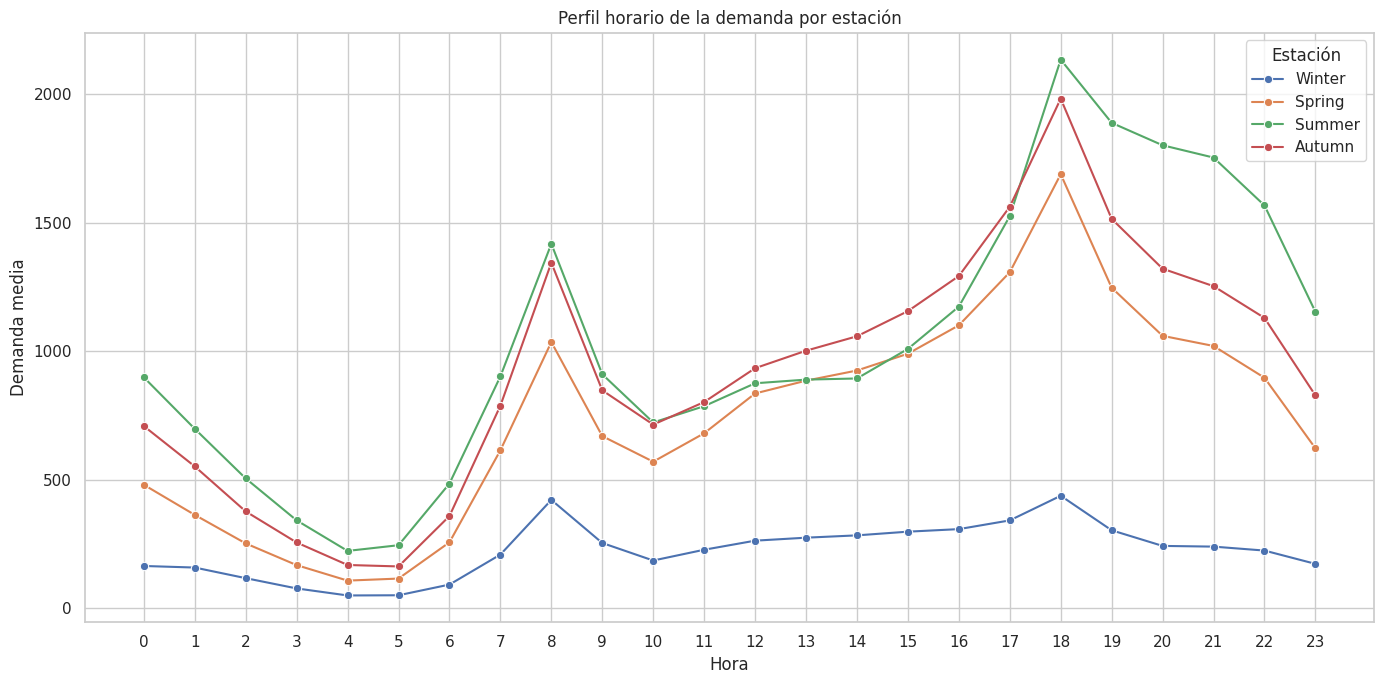

In [19]:
# Orden cronológico de las estaciones
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

df_operational["Seasons"] = pd.Categorical(
    df_operational["Seasons"],
    categories=season_order,
    ordered=True
)

# Resumen por estación
season_summary = (
    df_operational
    .groupby("Seasons", observed=True)["Rented Bike Count"]
    .agg(["mean", "median", "std", "count"])
    .round(1)
)

display(season_summary)

# Perfil horario por estación
season_hour_profile = (
    df_operational
    .groupby(
        ["Seasons", "Hour"],
        observed=True
    )["Rented Bike Count"]
    .mean()
    .reset_index()
)

# Hora de máxima demanda media en cada estación
season_peak_hours = (
    season_hour_profile
    .sort_values(
        ["Seasons", "Rented Bike Count"],
        ascending=[True, False]
    )
    .groupby("Seasons", observed=True)
    .head(1)
)

print("Hora de máxima demanda por estación:")
display(season_peak_hours)

# Visualización
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=season_hour_profile,
    x="Hour",
    y="Rented Bike Count",
    hue="Seasons",
    marker="o"
)

plt.title("Perfil horario de la demanda por estación")
plt.xlabel("Hora")
plt.ylabel("Demanda media")
plt.xticks(range(24))
plt.legend(title="Estación")
plt.tight_layout()
plt.show()

### Interpretación de la variación estacional

La demanda está fuertemente asociada con la estación. El verano presenta la mayor media, con 1.034 alquileres por hora, seguido del otoño con 924, la primavera con 746 y el invierno con 226.

La demanda media de verano es aproximadamente 4,59 veces la registrada en invierno. Sin embargo, esta diferencia no puede atribuirse exclusivamente a la temperatura, porque también pueden intervenir la lluvia, la nieve, las horas de luz y cambios estacionales en los hábitos de movilidad.

Las cuatro estaciones alcanzan su máxima demanda a las 18:00. Por tanto, el patrón horario se mantiene durante todo el año, aunque su intensidad cambia notablemente: la media de las 18:00 pasa de 438 alquileres en invierno a 2.135 en verano.

El análisis se limita a las horas operativas. Otoño contiene menos observaciones porque una parte de las interrupciones del servicio se concentra en esa estación.

## 14. Efecto descriptivo de los días festivos

Se compara la demanda entre días festivos y no festivos. También se analiza el perfil por hora, ya que una comparación global podría ocultar el desplazamiento o desaparición de las horas punta.

,mean,median,std,count
Holiday,,,,
Holiday,529.2,259.0,573.9,408
No Holiday,739.3,561.0,644.0,8057


Holiday,Holiday,No Holiday,Diferencia festivo (%)
Hour,,,
0,493.588235,564.901493,-12.6
1,416.470588,443.214925,-6.0
2,321.764706,312.313433,3.0
3,224.823529,210.131343,7.0
4,135.941176,137.567164,-1.2
5,94.235294,146.755224,-35.8
6,140.647059,306.179104,-54.1
7,226.882353,646.830357,-64.9
8,369.000000,1084.696429,-66.0


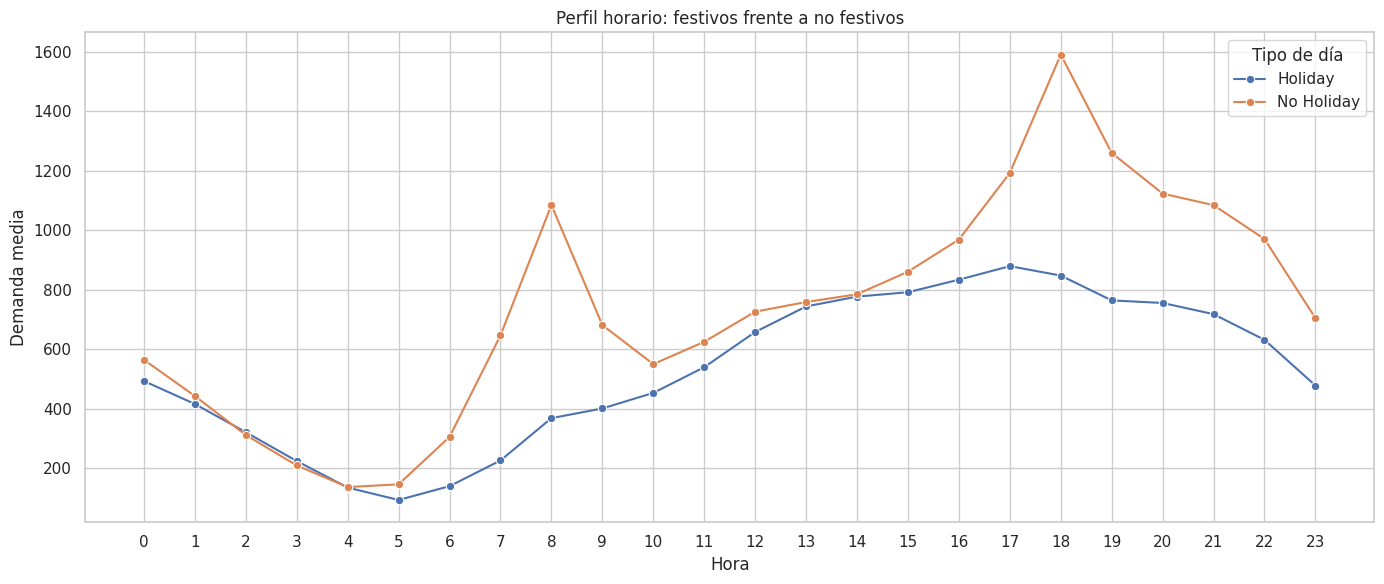

In [20]:
# Resumen general según festivo
holiday_summary = (
    df_operational
    .groupby("Holiday", observed=True)["Rented Bike Count"]
    .agg(["mean", "median", "std", "count"])
    .round(1)
)

display(holiday_summary)

# Perfil horario según festivo
holiday_hour_profile = (
    df_operational
    .groupby(
        ["Holiday", "Hour"],
        observed=True
    )["Rented Bike Count"]
    .mean()
    .reset_index()
)

# Comparación porcentual por hora
holiday_comparison = holiday_hour_profile.pivot(
    index="Hour",
    columns="Holiday",
    values="Rented Bike Count"
)

holiday_comparison["Diferencia festivo (%)"] = (
    (
        holiday_comparison["Holiday"]
        / holiday_comparison["No Holiday"]
        - 1
    )
    * 100
).round(1)

display(holiday_comparison)

# Visualización
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=holiday_hour_profile,
    x="Hour",
    y="Rented Bike Count",
    hue="Holiday",
    marker="o"
)

plt.title("Perfil horario: festivos frente a no festivos")
plt.xlabel("Hora")
plt.ylabel("Demanda media")
plt.xticks(range(24))
plt.legend(title="Tipo de día")
plt.tight_layout()
plt.show()

### Interpretación de los días festivos

La demanda es menor durante los días festivos. La media desciende de 739 alquileres por hora en días no festivos a 529 en festivos, una diferencia aproximada del 28,4 %. La mediana disminuye de 561 a 259.

La mayor diferencia aparece durante las horas asociadas a los desplazamientos cotidianos. A las 08:00, la demanda festiva es un 66,0 % inferior; a las 18:00, un 46,7 % inferior. En cambio, durante la madrugada las diferencias son pequeñas porque la demanda general ya es reducida.

Este resultado refuerza descriptivamente la relación entre el calendario laboral y los picos horarios. No obstante, la muestra solo contiene 408 horas festivas y los festivos pueden estar asociados con determinadas estaciones o días de la semana. Por ello, la comparación no demuestra un efecto causal independiente.

## 16. Demanda y condiciones meteorológicas

Se estudian las asociaciones entre demanda y variables meteorológicas mediante correlaciones de Spearman y comparaciones por intervalos de temperatura y presencia de lluvia. Estas asociaciones no implican causalidad y pueden estar condicionadas por la hora y la estación.

,Spearman
Rainfall,-0.305837
Snowfall,-0.246787
Humidity,-0.228348
Wind speed,0.154984
Visibility,0.198904
Solar Radiation,0.409508
Dew point temperature,0.410788
Temperature,0.611726


,mean,median,count
Rain status,,,
Con lluvia,167.3,71.0,516
Sin lluvia,765.6,591.0,7949


,mean,median,count
Temperature band,,,
≤ 0 °C,199.5,170.0,1454
0–10 °C,429.9,335.0,2117
10–20 °C,841.7,792.0,2058
20–30 °C,1150.4,1075.0,2324
> 30 °C,1106.4,903.0,512


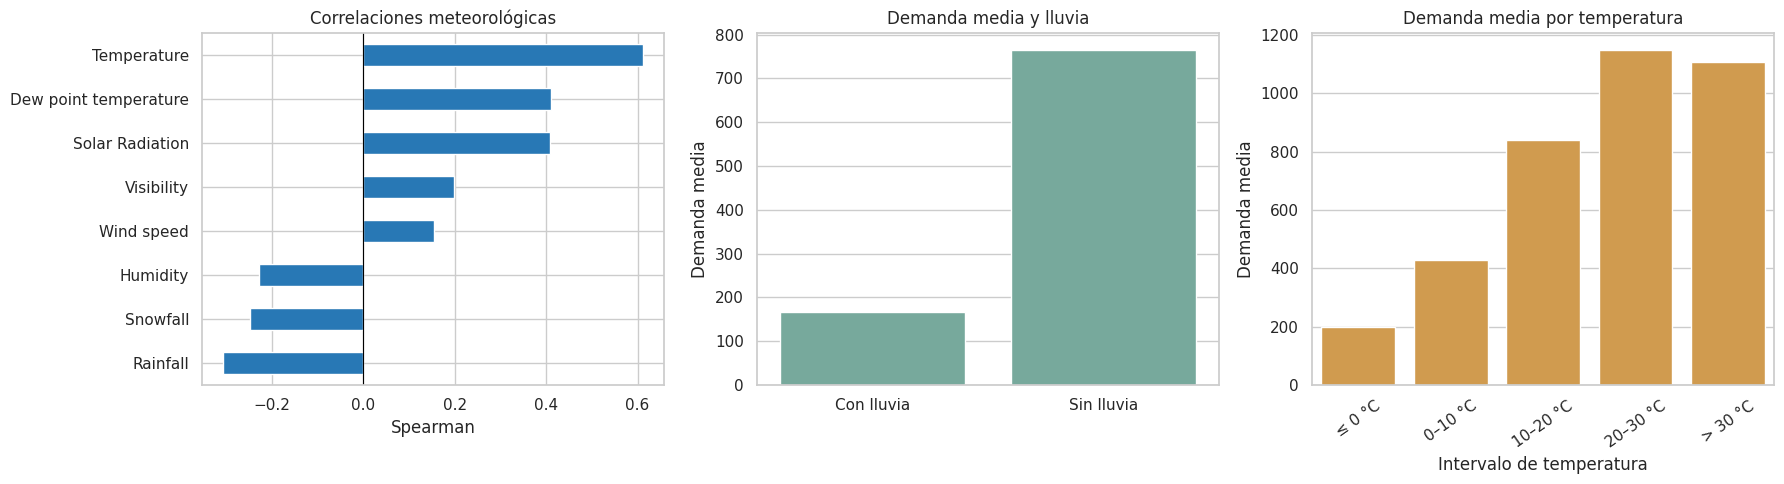

In [21]:
# Variables meteorológicas
weather_columns = [
    "Temperature",
    "Humidity",
    "Wind speed",
    "Visibility",
    "Dew point temperature",
    "Solar Radiation",
    "Rainfall",
    "Snowfall"
]

# Correlaciones de Spearman, adecuadas para asociaciones monotónicas
weather_correlations = (
    df_operational[
        ["Rented Bike Count"] + weather_columns
    ]
    .corr(method="spearman")["Rented Bike Count"]
    .drop("Rented Bike Count")
    .sort_values()
    .to_frame("Spearman")
)

display(weather_correlations)

# Clasificación según presencia de lluvia
df_operational["Rain status"] = np.where(
    df_operational["Rainfall"] > 0,
    "Con lluvia",
    "Sin lluvia"
)

rain_summary = (
    df_operational
    .groupby("Rain status", observed=True)["Rented Bike Count"]
    .agg(["mean", "median", "count"])
    .round(1)
)

display(rain_summary)

# Intervalos de temperatura
temperature_bins = [
    -np.inf,
    0,
    10,
    20,
    30,
    np.inf
]

temperature_labels = [
    "≤ 0 °C",
    "0–10 °C",
    "10–20 °C",
    "20–30 °C",
    "> 30 °C"
]

df_operational["Temperature band"] = pd.cut(
    df_operational["Temperature"],
    bins=temperature_bins,
    labels=temperature_labels,
    include_lowest=True
)

temperature_summary = (
    df_operational
    .groupby(
        "Temperature band",
        observed=True
    )["Rented Bike Count"]
    .agg(["mean", "median", "count"])
    .round(1)
)

display(temperature_summary)

# Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

weather_correlations.sort_values("Spearman").plot.barh(
    ax=axes[0],
    legend=False,
    color="#2878B5"
)

axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlaciones meteorológicas")
axes[0].set_xlabel("Spearman")

sns.barplot(
    data=rain_summary.reset_index(),
    x="Rain status",
    y="mean",
    ax=axes[1],
    color="#6FB1A0"
)

axes[1].set_title("Demanda media y lluvia")
axes[1].set_xlabel("")
axes[1].set_ylabel("Demanda media")

sns.barplot(
    data=temperature_summary.reset_index(),
    x="Temperature band",
    y="mean",
    ax=axes[2],
    color="#E59F3A"
)

axes[2].set_title("Demanda media por temperatura")
axes[2].set_xlabel("Intervalo de temperatura")
axes[2].set_ylabel("Demanda media")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 15. Registro de decisiones y limitaciones